# Exploration des Radiographies (BrainScanAI)

Ce notebook implémente l'audit technique et l'exploration visuelle du dataset conformément aux conventions définies dans `skills/exploration.md`.

In [1]:
# Importation des bibliothèques et configuration des chemins d'accès au dataset.
#  Dataset directory path
#  Lists of images paths (labeled/unlabeled)
import os
import glob
import random
import json
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

dataset_dir = '../data/raw/mri_dataset_brain_cancer_oc'
unlabeled_dir = os.path.join(dataset_dir, 'sans_label')
labeled_dir = os.path.join(dataset_dir, 'avec_labels')

valid_ext = ('.jpg', '.jpeg', '.png')
unlabeled_images = [f for f in glob.glob(os.path.join(unlabeled_dir, '**', '*.*'), recursive=True) if f.lower().endswith(valid_ext)]

normal_images = [f for f in glob.glob(os.path.join(labeled_dir, 'Normal', '*.*'), recursive=True) if f.lower().endswith(valid_ext)]
cancer_images = [f for f in glob.glob(os.path.join(labeled_dir, 'Cancer', '*.*'), recursive=True) if f.lower().endswith(valid_ext)]
labeled_images = normal_images + cancer_images

In [2]:
# Échantillonnage du dataset à hauteur de 10% pour l'analyse exploratoire.
#  Full image lists
#  Sampled image lists
# 4. Échantillonnage (Recommandation : 10%)
sample_ratio = 0.10
sampled_unlabeled = random.sample(unlabeled_images, int(len(unlabeled_images) * sample_ratio)) if unlabeled_images else []
sampled_normal = random.sample(normal_images, int(len(normal_images) * sample_ratio)) if normal_images else []
sampled_cancer = random.sample(cancer_images, int(len(cancer_images) * sample_ratio)) if cancer_images else []

sampled_all = sampled_normal + sampled_cancer + sampled_unlabeled
print(f"Taille de l'échantillon unlabeled data : {len(sampled_unlabeled)}")
print(f"Taille de l'échantillon  Normal data : {len(sampled_normal)}")
print(f"Taille de l'échantillon  cancer data : {len(sampled_cancer)}")
print(f"Taille de l'échantillon de travail (10%) : {len(sampled_all)} images")

Taille de l'échantillon unlabeled data : 140
Taille de l'échantillon  Normal data : 5
Taille de l'échantillon  cancer data : 5
Taille de l'échantillon de travail (10%) : 150 images


In [3]:
# Audit technique des images (résolutions, canaux) et sauvegarde du résumé statistique.
#  Sampled images
#  data_summary.json and audit report
# 2. Audit Technique (Résolution, Canaux, Statistiques)
resolutions = set()
channels = set()

for img_path in sampled_all:
    with Image.open(img_path) as img:
        resolutions.add(img.size)
        channels.add(img.mode)

metrics = {
    "total_images": len(unlabeled_images) + len(labeled_images),
    "repartition": {
        "non_labellise": len(unlabeled_images),
        "normal": len(normal_images),
        "cancereux": len(cancer_images)
    },
    "echantillon_audit": len(sampled_all),
    "resolutions_trouvees": [f"{w}x{h}" for w, h in resolutions],
    "canaux_trouves": list(channels)
}

print("Résultats de l'audit technique :")
print(json.dumps(metrics, indent=4))

# Sauvegarder dans data_summary.json
with open('../data/data_summary.json', 'w') as f:
    json.dump(metrics, f, indent=4)
print("\nMétriques sauvegardées dans ../data/data_summary.json")

Résultats de l'audit technique :
{
    "total_images": 1506,
    "repartition": {
        "non_labellise": 1406,
        "normal": 50,
        "cancereux": 50
    },
    "echantillon_audit": 150,
    "resolutions_trouvees": [
        "512x512"
    ],
    "canaux_trouves": [
        "RGB"
    ]
}

Métriques sauvegardées dans ../data/data_summary.json


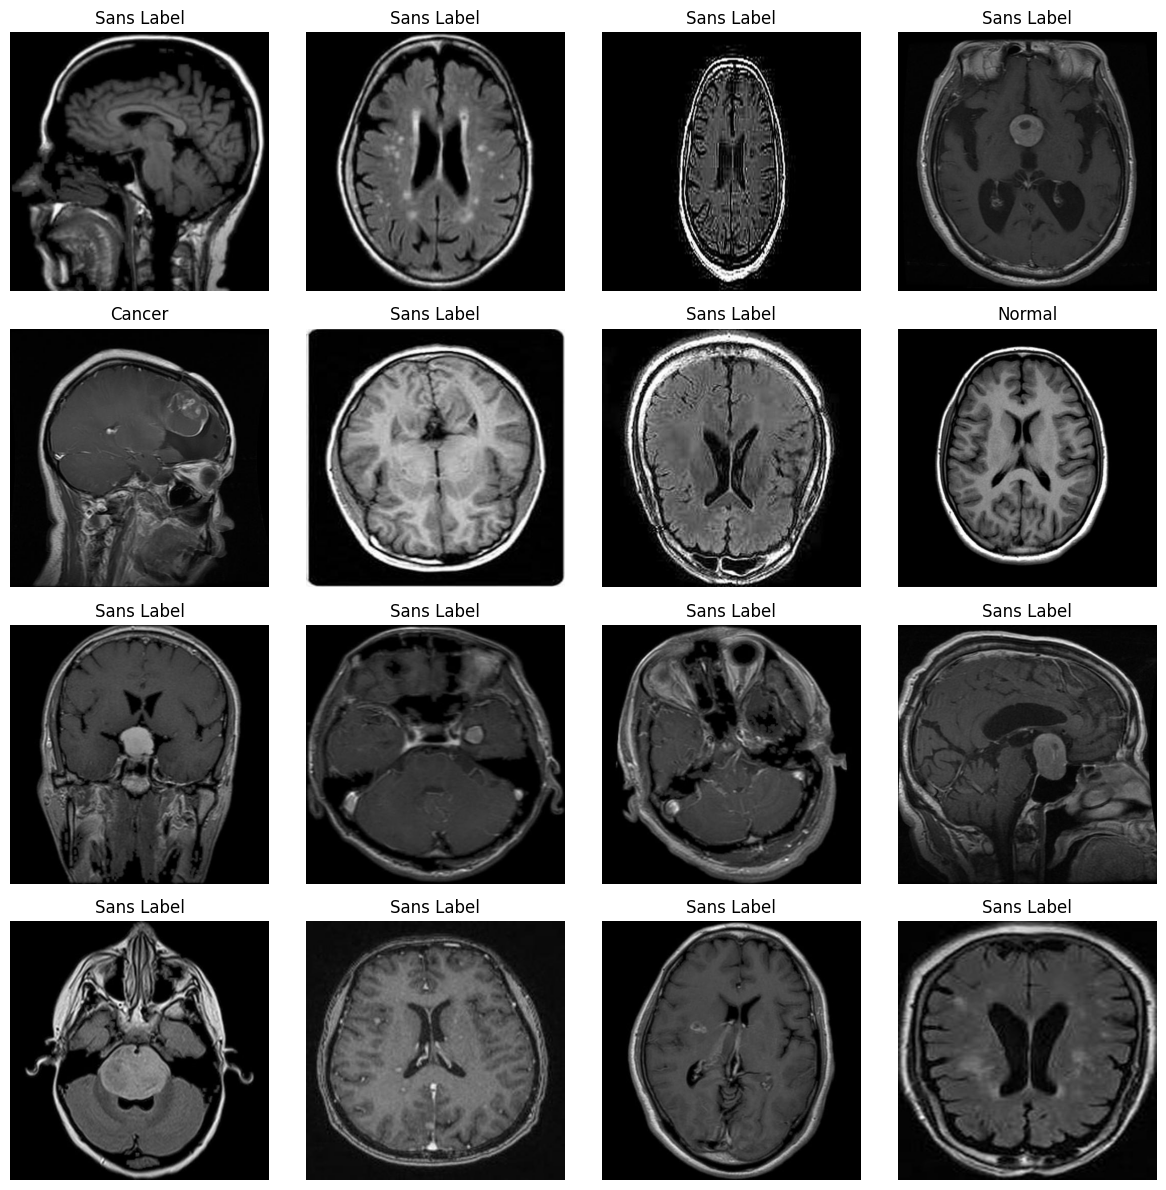

In [4]:
# Visualisation d'un échantillon d'images pour validation visuelle.
#  Image paths
#  Matplotlib plots
# 3. Visualisation : Grille de 16 images aléatoires avec labels et colormap 'bone'
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

# Prendre 16 images au hasard (ou toutes si < 16)
images_to_plot = random.sample(sampled_all, min(16, len(sampled_all))) if sampled_all else []

for ax, img_path in zip(axes, images_to_plot):
    parent_dir = os.path.basename(os.path.dirname(img_path)) 
    label = parent_dir if parent_dir in ['Normal', 'Cancer'] else 'Sans Label'
    
    img = Image.open(img_path)
    ax.imshow(img, cmap='bone' if img.mode == 'L' else None)
    ax.set_title(label)
    ax.axis('off')

# Cacher les axes restants si moins de 16 images
for i in range(len(images_to_plot), 16):
    axes[i].axis('off')

plt.tight_layout()
plt.show()